# WiniCari — 03 Delay

> 📖 **Unfamiliar terms?** See [docs/GLOSSARY.md](../docs/GLOSSARY.md) — elapsed-to-stop, baseline / expected_min, delay_min, rolling next-stop prediction, persistence vs naive, MAE, serve_eta, day-type, …

**Module 1: predict how late a bus will be — before it happens.**

There are **no official per-stop timetables** in the data (`ligne.horaires` only stores
origin departure times). So we measure delay against a **data-driven baseline**: the typical
time each line takes to reach each stop, learned from all the trips reconstructed in
`02_preprocessing`.

> **delay = actual elapsed-to-stop − expected elapsed-to-stop (baseline)**

⚠️ This is delay *relative to how the line normally performs* ("this run is slower than
usual / disrupted"), **not** lateness vs a published schedule. If the company later provides
real per-stop timetables, we swap the baseline for that schedule and nothing else changes.

Logic lives in **`src/data/delay.py`**; this notebook demonstrates it, trains the rolling
predictor, and serves ETAs.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error

from src.data import delay as dl

CFG = dl.DelayConfig()
FOUNDATION = Path(dl.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"

df = dl.load_foundation(FOUNDATION)
m = dl.add_daytype(dl.with_elapsed(df, CFG))    # matched arrivals + elapsed + calendar features
baseline = dl.build_baseline(m, CFG)            # data-driven 'schedule'
d = dl.add_daytype(dl.with_delay(m, baseline, CFG))   # + delay_min

print(f"arrivals={len(m):,} | baseline cells (>= {CFG.min_obs} trips)={len(baseline)} | "
      f"rows with delay={len(d):,}")
print(f"day range: {d['day'].min()} .. {d['day'].max()} | lines={d['line'].nunique()}")
d[["day", "line", "dir", "seq", "stop", "elapsed_min", "expected_min", "delay_min"]].head()

arrivals=129,973 | baseline cells (>= 20 trips)=554 | rows with delay=128,031
day range: 20250101 .. 20260621 | lines=16


,day,line,dir,seq,stop,elapsed_min,expected_min,delay_min
0,20250101,217,ALLER,0,KASSERINE,0.500017,2.923050,-2.423033
1,20250101,217,ALLER,1,BOUZGUEM,13.249483,18.410633,-5.161150
2,20250101,217,ALLER,3,CHRAYA,23.150600,29.954750,-6.804150
3,20250101,217,ALLER,4,SBEITLA,38.532983,46.949717,-8.416733
4,20250101,217,ALLER,5,M'GHILLA,57.032967,64.238875,-7.205908


## 1. The data-driven baseline (our "schedule")

For every `(societe, line, dir, stop)` the baseline is the **median** elapsed time from the
trip start, with a p10–p90 band showing normal spread. A run is "delayed" when it sits above
this curve.

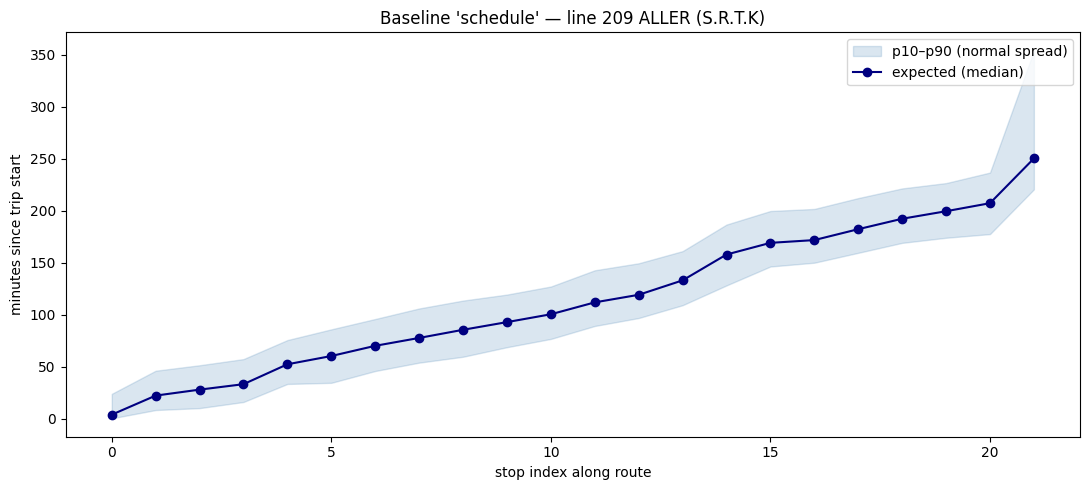

trips per line (top 10):
societe  line
TCV      3       14271
S.T.S    101      1633
         219       666
S.R.T.K  212       629
S.T.S    304       407
S.R.T.K  203       293
         217       288
         215       276
         209       244
         204       209


In [2]:
SOC, LINE, DIR = "S.R.T.K", "209", "ALLER"
b = baseline[(baseline.societe == SOC) & (baseline.line == LINE) & (baseline["dir"] == DIR)].sort_values("seq")

plt.figure(figsize=(11, 5))
plt.fill_between(b["seq"], b["p10"], b["p90"], alpha=0.2, color="steelblue", label="p10–p90 (normal spread)")
plt.plot(b["seq"], b["expected_min"], "o-", color="navy", label="expected (median)")
plt.xlabel("stop index along route"); plt.ylabel("minutes since trip start")
plt.title(f"Baseline 'schedule' — line {LINE} {DIR} ({SOC})")
plt.legend(); plt.tight_layout(); plt.show()

tpl = (d.groupby(["societe", "line"])[dl.TRIP_KEYS]
         .apply(lambda x: x.drop_duplicates().shape[0])
         .sort_values(ascending=False).rename("trips"))
print("trips per line (top 10):"); print(tpl.head(10).to_string())

## 2. Delay = actual − expected

Centered near zero by construction; the **spread, the tails, and when they happen** are the
disruption signal.

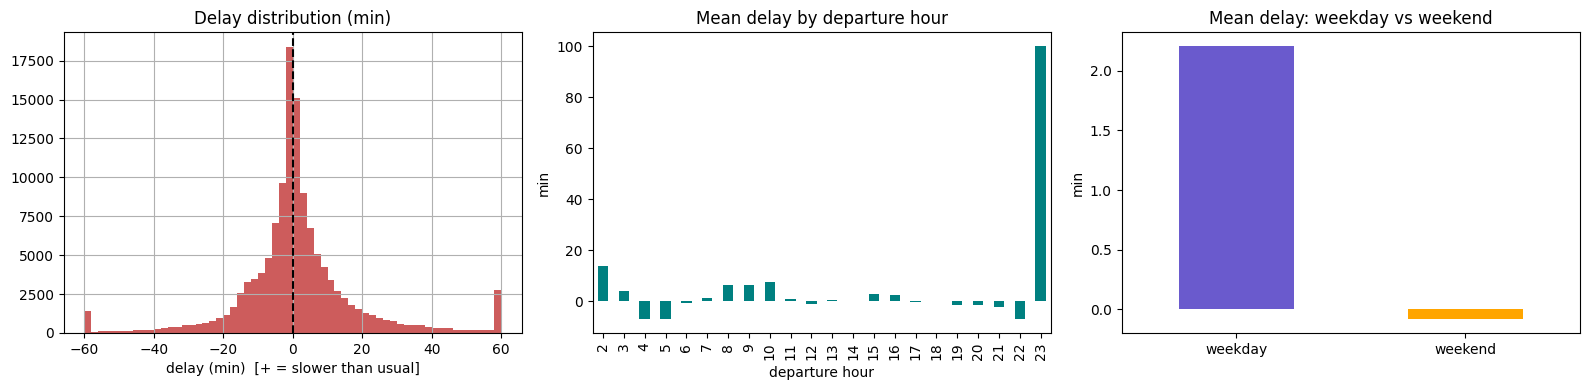

mean      1.7
std      21.6
min    -120.0
25%      -4.9
50%       0.0
75%       6.5
max     120.0


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
d["delay_min"].clip(-60, 60).hist(bins=60, ax=ax[0], color="indianred")
ax[0].axvline(0, color="black", ls="--"); ax[0].set_title("Delay distribution (min)")
ax[0].set_xlabel("delay (min)  [+ = slower than usual]")

d.groupby("dep_hour")["delay_min"].mean().plot(kind="bar", ax=ax[1], color="teal")
ax[1].set_title("Mean delay by departure hour"); ax[1].set_xlabel("departure hour"); ax[1].set_ylabel("min")

wk = d.groupby("is_weekend")["delay_min"].mean()
wk.index = ["weekday", "weekend"]
wk.plot(kind="bar", ax=ax[2], color=["slateblue", "orange"])
ax[2].set_title("Mean delay: weekday vs weekend"); ax[2].set_ylabel("min"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print(d["delay_min"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1).to_string())

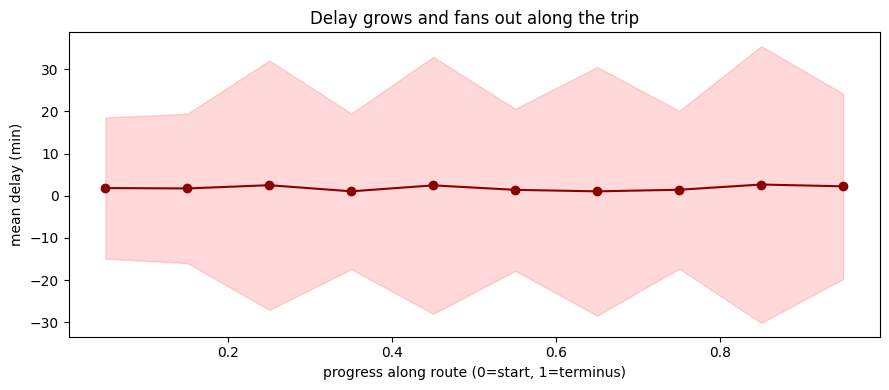

In [4]:
# Delay GROWS along the trip (small early slips compound) — why rolling prediction works
d["seq_frac"] = d.groupby(dl.TRIP_KEYS)["seq"].transform(lambda s: s / s.max() if s.max() else 0)
growth = d.groupby(pd.cut(d["seq_frac"], np.linspace(0, 1, 11), include_lowest=True),
                   observed=True)["delay_min"].agg(["mean", "std"])
xs = np.linspace(0.05, 0.95, len(growth))
plt.figure(figsize=(9, 4))
plt.plot(xs, growth["mean"], "o-", color="darkred")
plt.fill_between(xs, growth["mean"] - growth["std"], growth["mean"] + growth["std"], alpha=0.15, color="red")
plt.xlabel("progress along route (0=start, 1=terminus)"); plt.ylabel("mean delay (min)")
plt.title("Delay grows and fans out along the trip"); plt.tight_layout(); plt.show()

## 3. Rolling prediction — delay one stop ahead → full ETA

The operator/passenger app needs an **ETA for every remaining stop**, updated as the bus
moves. So we train a model to predict the delay at the **next** stop from the bus's current
state (`rolling_table` + `train_rolling_model`), then chain it forward into an ETA
(`serve_eta`). Train/test split is **by day** (no leakage).

In [5]:
roll = dl.rolling_table(d)
days = np.sort(roll["day"].unique())
cut_day = days[int(0.8 * len(days))]
tr, te = roll[roll["day"] < cut_day], roll[roll["day"] >= cut_day]

model = dl.train_rolling_model(tr)
pred = model.predict(dl._design(te))

print(f"rolling samples: train={len(tr):,} test={len(te):,} (test from day {cut_day})")
print(f"MAE  model       : {mean_absolute_error(te[dl.TARGET], pred):.2f} min")
print(f"MAE  persistence : {mean_absolute_error(te[dl.TARGET], te['delay_min']):.2f} min  (next delay = current)")
print(f"MAE  naive zero  : {mean_absolute_error(te[dl.TARGET], np.zeros(len(te))):.2f} min  (on time)")

rolling samples: train=96,262 test=12,089 (test from day 20260302)
MAE  model       : 2.73 min
MAE  persistence : 3.04 min  (next delay = current)
MAE  naive zero  : 13.77 min  (on time)


,seq,expected_min,pred_delay_min,eta
0,6,70.2,8.4,07:18
1,7,77.8,8.7,07:26
2,8,85.6,8.6,07:34
3,9,93.0,8.7,07:41
4,10,100.5,8.7,07:49
5,11,112.0,9.4,08:01
6,12,119.3,10.0,08:09
7,13,133.2,9.8,08:22
8,14,158.0,9.9,08:47
9,15,169.3,10.4,08:59


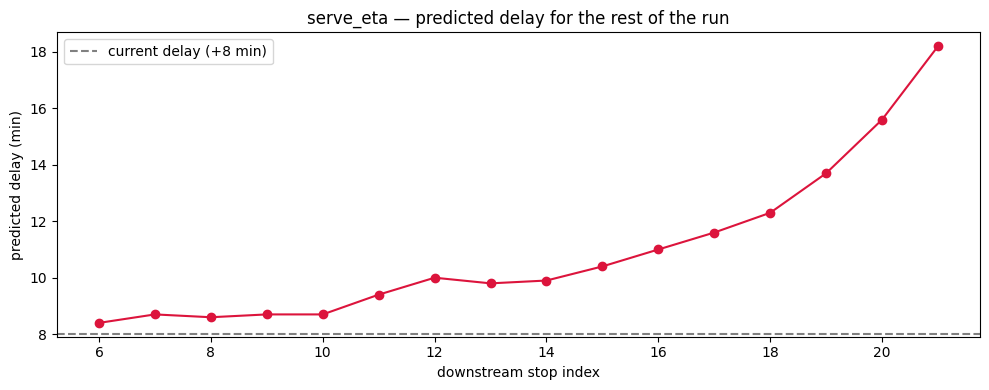

In [6]:
# SERVE an ETA: a bus on line 209 ALLER, currently at stop 5, running 8 min late.
eta = dl.serve_eta(model, baseline, societe="S.R.T.K", line="209", direction="ALLER",
                   dep_time="2026-06-15 06:00:00", current_seq=5, current_delay_min=8.0)
display(eta.assign(eta=eta["eta"].dt.strftime("%H:%M")).head(16))

plt.figure(figsize=(10, 4))
plt.plot(eta["seq"], eta["pred_delay_min"], "o-", color="crimson")
plt.axhline(8.0, color="grey", ls="--", label="current delay (+8 min)")
plt.xlabel("downstream stop index"); plt.ylabel("predicted delay (min)")
plt.title("serve_eta — predicted delay for the rest of the run"); plt.legend()
plt.tight_layout(); plt.show()

### Takeaways & next steps

- **Rolling next-stop model:** MAE **~2.7 min**, beating persistence (≈3.0) and far better than
  naive — and `serve_eta` chains it into a live ETA for every remaining stop.
- **Day-type helps:** weekends run measurably closer to baseline than weekdays (feature
  `is_weekend`). *Weather* would likely help too but needs an external source (not in the DB).
- **What "delay" means here:** vs the line's *own typical* performance, not a published
  timetable — good for disruption alerts and ETA messaging; true schedule adherence still
  needs the company's per-stop timetables.
- **Quality gating:** delay is only as good as the per-line arrival match rate (see
  `02_preprocessing`); exclude or fix low-match lines.
- **Still to do:** fold **dwell/stoppage** into the foundation (then rebuild) so the model can
  see how long the bus actually sits at stops — most useful for Anomaly detection.